# Dog vs Cat Image Classification using SVM

## Objective

Build a Support Vector Machine (SVM) model to classify images as either Cat or Dog.

## Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


## Load the Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
path="/content/drive/Othercomputers/My Laptop/Downloads/train/train"
print(os.listdir(path))

['dog.91.jpg', 'dog.9099.jpg', 'dog.910.jpg', 'dog.9100.jpg', 'dog.9101.jpg', 'dog.9102.jpg', 'dog.9103.jpg', 'dog.9104.jpg', 'dog.9105.jpg', 'dog.9106.jpg', 'dog.9107.jpg', 'dog.9108.jpg', 'dog.9109.jpg', 'dog.911.jpg', 'dog.9110.jpg', 'dog.9111.jpg', 'dog.9112.jpg', 'dog.9114.jpg', 'dog.9113.jpg', 'dog.9116.jpg', 'dog.9115.jpg', 'dog.9117.jpg', 'dog.9118.jpg', 'dog.9119.jpg', 'dog.912.jpg', 'dog.9120.jpg', 'dog.9121.jpg', 'dog.9122.jpg', 'dog.9123.jpg', 'dog.9124.jpg', 'dog.9125.jpg', 'dog.9127.jpg', 'dog.9126.jpg', 'dog.9128.jpg', 'dog.9129.jpg', 'dog.913.jpg', 'dog.9130.jpg', 'dog.9131.jpg', 'dog.9132.jpg', 'dog.9133.jpg', 'dog.9134.jpg', 'dog.9136.jpg', 'dog.9135.jpg', 'dog.9138.jpg', 'dog.9137.jpg', 'dog.9140.jpg', 'dog.914.jpg', 'dog.9139.jpg', 'dog.9141.jpg', 'dog.9142.jpg', 'dog.9143.jpg', 'dog.9144.jpg', 'dog.9145.jpg', 'dog.9146.jpg', 'dog.9147.jpg', 'dog.9148.jpg', 'dog.9149.jpg', 'dog.915.jpg', 'dog.9150.jpg', 'dog.9151.jpg', 'dog.9152.jpg', 'dog.9153.jpg', 'dog.9154.jpg',

## Create a Dataset Subset

Select 1000 cat images and 1000 dog images for training.

In [5]:

import shutil

source_folder = "/content/drive/Othercomputers/My Laptop/Downloads/train/train"

destination_folder = "/content/drive/Othercomputers/My Laptop/Downloads/train/train_subset"

os.makedirs(destination_folder, exist_ok=True)

cat_count = 0
dog_count = 0

for filename in sorted(os.listdir(source_folder)):
    if filename.startswith("cat.") and cat_count < 1000:
        shutil.copy(
            os.path.join(source_folder, filename),
            os.path.join(destination_folder, filename)
        )
        cat_count += 1

    elif filename.startswith("dog.") and dog_count < 1000:
        shutil.copy(
            os.path.join(source_folder, filename),
            os.path.join(destination_folder, filename)
        )
        dog_count += 1

    if cat_count == 1000 and dog_count == 1000:
        break

print("Subset created successfully!")
print("Cats:", cat_count)
print("Dogs:", dog_count)

Subset created successfully!
Cats: 1000
Dogs: 1000


## Check the Dataset

In [9]:
import os

dataset_path = "/content/drive/Othercomputers/My Laptop/Downloads/train/train_subset"

print(len(os.listdir(dataset_path)))
print(os.listdir(dataset_path)[:10])

2000
['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10002.jpg', 'cat.10003.jpg', 'cat.10004.jpg']


## Read One Image

(374, 500, 3)


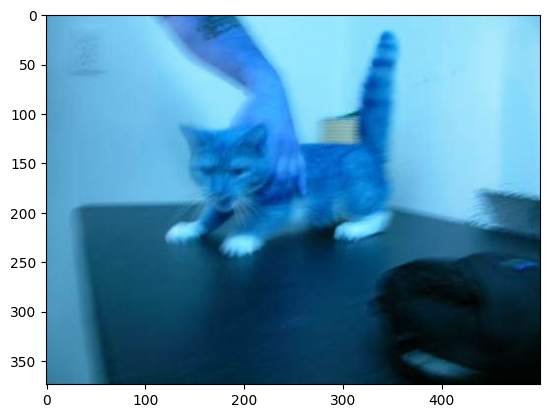

In [10]:
image_path=os.path.join(dataset_path,"cat.0.jpg")
img=cv2.imread(image_path)
print(img.shape)
plt.imshow(img)
plt.show()

## Convert BGR to RGB

OpenCV reads images in BGR format.
Convert them to RGB for correct display.

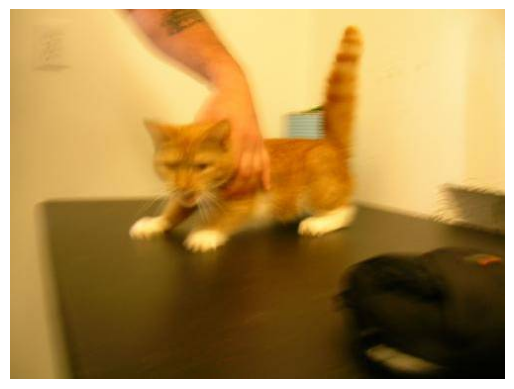

In [12]:
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

## Resize the Image

Resize all images to 64 × 64 pixels.

In [16]:
img=cv2.imread(image_path)
resized_img=cv2.resize(img,(64,64))
print(img.shape)
print(resized_img.shape)

(374, 500, 3)
(64, 64, 3)


## Prepare the Dataset

Read all images, resize them, flatten them and create labels.

Cat = 0

Dog = 1

In [38]:
images = []
labels = []
files = os.listdir(dataset_path)
for filename in files:
  image_paths=os.path.join(dataset_path,filename)
  image=cv2.imread(image_paths)
  resize_img=cv2.resize(image,(64,64))
  images.append(resize_img.flatten())
  if filename.startswith('cat'):
    labels.append(0)
  else:
    labels.append(1)

## Convert to NumPy Arrays

In [30]:
X=np.array(images, dtype=np.float32)
y=np.array(labels)
print(X.shape)
print(y.shape)

(2000, 12288)
(2000,)


## Split the Dataset

Split the data into training and testing sets.

In [31]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


## Train the SVM Model

In [32]:
model=SVC(kernel='rbf',random_state=42,C=1)

In [33]:
model.fit(X_train,y_train)

SVC(C=1, random_state=42)

## Make Predictions

In [34]:
y_prediction=model.predict(X_test)

In [35]:
y_prediction

array([0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,

## Evaluate the Model

In [36]:
accuracy = accuracy_score(y_test, y_prediction)

print("Accuracy:", accuracy)

Accuracy: 0.8425


In [37]:
print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

           0       0.64      0.63      0.64       199
           1       0.64      0.65      0.65       201

    accuracy                           0.64       400
   macro avg       0.64      0.64      0.64       400
weighted avg       0.64      0.64      0.64       400



## Conclusion

The SVM model was trained to classify cat and dog images.

The model achieved an accuracy of **84.25%** on the test dataset.

This project helped me understand image preprocessing, SVM classification and model evaluation.